 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           :Konrad Psiuk<br>
Student Number : L00169810         <br>
Due Date       :                 <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [3]:
# pip installs
!pip install spacy nltk scikit-learn pandas numpy matplotlib PyPDF2 pytesseract pymupdf


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Imports

In [24]:
# imports
import nltk
import spacy
import pytesseract
import cv2
import matplotlib.pyplot as plt
from pytesseract import Output
import re

nltk.download('punkt',      quiet=True)
nltk.download('stopwords',  quiet=True)
nltk.download('punkt_tab',  quiet=True)

nlp = spacy.load('en_core_web_sm')

pytesseract.pytesseract.tesseract_cmd = r'/opt/homebrew/bin/tesseract'


# Support Functions

In [19]:
def extract_text_from_image(image_path: str) -> str:
    img = cv2.imread(image_path)
    custom_config = r'--oem 1 --psm 6'
    return pytesseract.image_to_string(img, config=custom_config)

In [20]:
img_clean = cv2.imread('TextCleansing.jpg')
print(f'Image shape (height, width, channels): {img_clean.shape}')
custom_config = r'--oem 1 --psm 6'
ocr_text_clean = pytesseract.image_to_string(img_clean, config=custom_config)

print('OCR Output')
print(ocr_text_clean)

Image shape (height, width, channels): (2200, 1700, 3)
OCR Output
Text Wrangling and Cleansin,

Text cleansing

Once we have parsed the text from a variety of data sources, the challenge is to

make sense of this raw data. Text cleansing is loosely used for most of the cleaning

to be done on text, depending on the data source, parsing performance, external

noise and so on. In that sense, what we did in Chapter 1, Introduction to Natural

Language Processing for cleaning the html using htm1_clean, can be labeled as text

cleansing. In another case, where we are parsing a PDF, there could be unwanted

noisy characters, non ASCII characters to be removed, and so on. Before going on to

next steps we want to remove these to get a clean text to process further. With a data

source like xm1, we might only be interested in some specific elements of the tree,

with databases we may have to manipulate splitters, and sometimes we are only

interested in specific columns. In summary, any proces

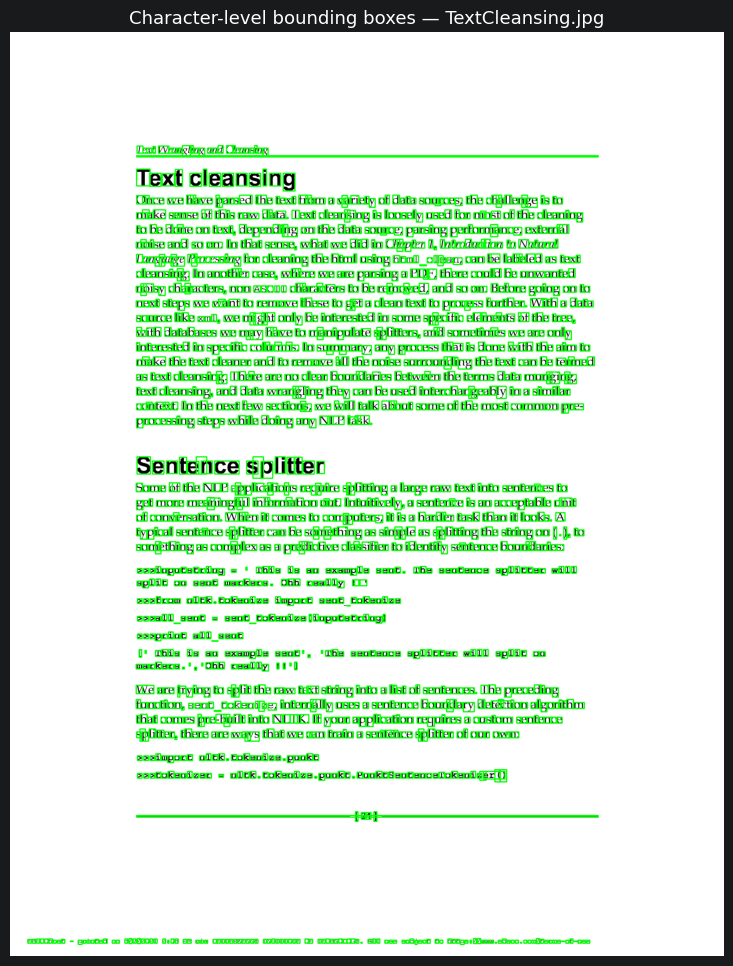

In [21]:
img_boxes = cv2.imread('TextCleansing.jpg')
h, w, c   = img_boxes.shape

boxes = pytesseract.image_to_boxes(img_boxes)

for b in boxes.splitlines():
    b = b.split(' ')
    img_boxes = cv2.rectangle(
        img_boxes,
        (int(b[1]), h - int(b[2])),
        (int(b[3]), h - int(b[4])),
        (0, 255, 0), 2   # green, thickness 2
    )

plt.figure(figsize=(16, 12))
plt.imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Character-level bounding boxes — TextCleansing.jpg', fontsize=13)
plt.show()

In [23]:
img_search = cv2.imread('TextCleansing.jpg')

d = pytesseract.image_to_data(img_search, output_type=Output.DICT)

print('Keys returned by image_to_data:')
print(list(d.keys()))
print(f'\nTotal word entries: {len(d["text"])}')

Keys returned by image_to_data:
['level', 'page_num', 'block_num', 'par_num', 'line_num', 'word_num', 'left', 'top', 'width', 'height', 'conf', 'text']

Total word entries: 499


Pattern "(NLP)" found 2 time(s) with confidence > 60%


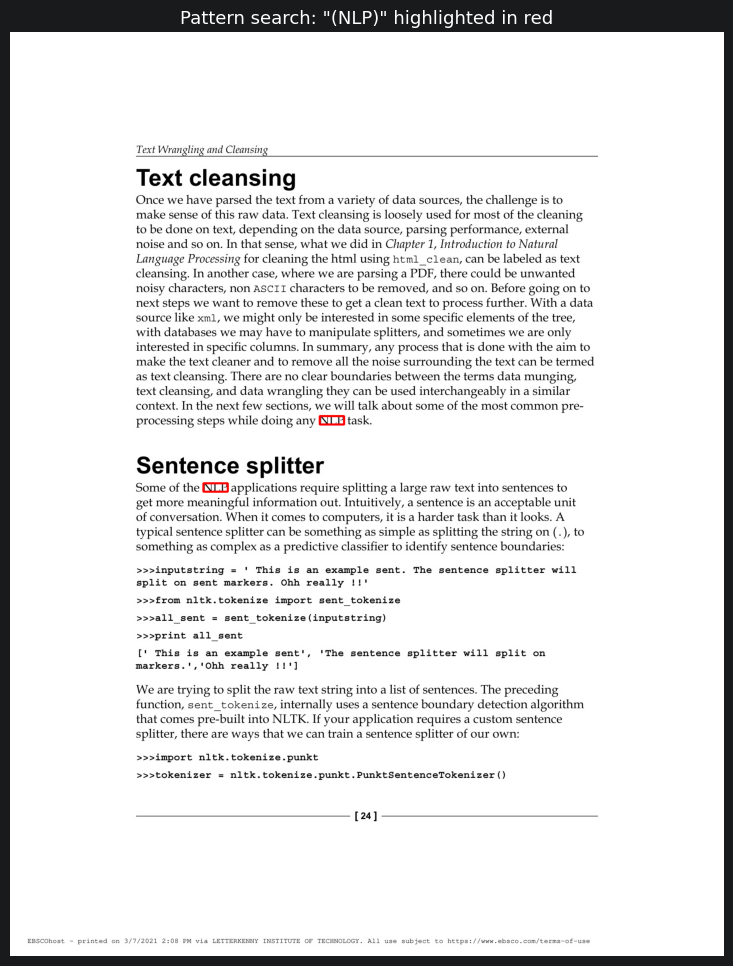

In [26]:
img_search = cv2.imread('TextCleansing.jpg')

search_term = r'(NLP)'

n_boxes  = len(d['text'])
matches  = 0

for i in range(n_boxes):
    if int(d['conf'][i]) > 60:
        if re.match(search_term, d['text'][i]):
            x, y, ww, hh = d['left'][i], d['top'][i], d['width'][i], d['height'][i]
            img_search = cv2.rectangle(img_search, (x, y), (x + ww, y + hh), (0, 0, 255), 3)  # red
            matches += 1

print(f'Pattern "{search_term}" found {matches} time(s) with confidence > 60%')

plt.figure(figsize=(16, 12))
plt.imshow(cv2.cvtColor(img_search, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'Pattern search: "{search_term}" highlighted in red', fontsize=13)
plt.show()